# Investment-Linked Insurance with GMDB Simulation
## Monte Carlo Projection & Guarantee Risk Analysis  
## 1. Objective

本專案建立一個投資型壽險（Investment-Linked Insurance）之模擬模型，透過 Monte Carlo 方法，在相同隨機路徑下比較不同 GMDB（Guaranteed Minimum Death Benefit）設計之表現。

分析重點包括帳戶價值（Account Value, AV）、死亡給付（Death Benefit, DB）、保證成本（Guarantee Cost, GC）以及尾端風險（Tail Risk），以評估不同保證結構對保單風險與成本之影響。

在方法上，本研究同時採用兩種分析架構：

1. **Real-world 模擬（實際機率）**：用以評估保單在既定假設下的損益分布與風險特性。
2. **Risk-neutral 評價（風險中立）**：用以衡量保證機制在無套利條件下的經濟價值。

本專案透過「實際損失」與「市場定價」兩個面向，全面分析 GMDB 設計對產品風險與經濟成本之影響。

## 2. Product Design & Model Assumptions

### 2.1 商品架構

本商品為投資型壽險，其核心機制如下：

- 保戶繳納保費 → 投入投資標的形成帳戶價值（AV）
- 每期扣除費用與保險成本（COI）
- 死亡時依 GMDB 結構給付死亡保險金

### 2.2 GMDB 設計

#### (1) Basic : 固定保額160萬，提供最低保障
$$ DB = \max(\text{Basic Amount}, AV)$$

#### (2) Ratchet : 初始guarantee base為160萬，在特定期數若AV大於當前GB則更新GB ，在上漲時鎖住收益
$$ GB_t = \max(GB_{t-1}, AV_t) $$  

$$ DB = \max(GB, AV) $$

#### (3) Roll-up : guarantee base 隨時間成長，提供時間累積型保障
$$ GB_t = \text{Basic Amount} \times (1 + g)^t $$  

$$ DB = \max(GB, AV) $$

### 2.3 模型假設

- 投資報酬：GBM（Geometric Brownian Motion）
- 死亡率：依 mortality table
- 解約率：依 lapse assumption (當前模型未模擬解約率，唯AV不足支付Total fee時保單會失效)
- 模擬方式：Monte Carlo（多路徑）

## 3. Model Framework

### 3.1 Product Configuration

設定商品參數：

- 投保年齡
- 保額
- 投資報酬參數（$\mu$, $\sigma$）
- GMDB 類型 (可設定為 "basic", "ratchet", "rollup")
----------


##### *程式碼註記 -> Demo 模型初始值設定 ProductConfig  
投保年齡 = 40歲 男性  , 躉繳保費 = 1,000,000 (不提領、不追加保費) , 帳戶價值初值AV = 997,664   

保額 = 1,600,000  , 保單年限20年 ，一個月一期  , 投資報酬率假設  $\mu$ = 0.04, $\sigma$ = 0.1  , 折現率 = 0.02  
  
*ratchet_frequency 預設12個月 lock-in 一次  ； rollup_rate 年化保證成長率 = 0.03

In [95]:
from dataclasses import dataclass, asdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# 1. Product Config
@dataclass
class ProductConfig:
    issue_age: int = 40
    gender: str = "M"
    single_premium: float = 1_000_000
    initial_investment: float = 997_664
    basic_amount: float = 1_600_000

    policy_years: int = 20
    steps_per_year: int = 12

    mu: float = 0.04          # annual expected return
    sigma: float = 0.10       # annual volatility
    discount_rate: float = 0.02

    monthly_fixed_admin_fee: float = 100.0

    # GMDB 設定
    gmdb_type: str = "basic"      # "basic", "ratchet", "rollup"
    ratchet_frequency: int = 12   # 幾個月 lock-in 一次，12 = 每年
    rollup_rate: float = 0.03     # 年化保證成長率

    def __post_init__(self):
        self.n_steps = self.policy_years * self.steps_per_year

##### *程式碼註記 ->  Class TABLE

In [97]:
# 2. Rate Table Classes
class RateTable:
    def __init__(self, table: dict):
        self.table = table

    def get(self, key: int) -> float:
        if key in self.table:
            return self.table[key]
        else:
            # 超出範圍時，先用最大年齡的值延伸
            max_key = max(self.table.keys())
            return self.table[max_key]


class COITable:
    def __init__(self, male_table: RateTable, female_table: RateTable):
        self.male = male_table
        self.female = female_table

    def get_rate(self, age: int, gender: str) -> float:
        return self.male.get(age) if gender == "M" else self.female.get(age)


class MortalityTable:
    def __init__(self, male_table: RateTable, female_table: RateTable):
        self.male = male_table
        self.female = female_table

    def get_qx(self, age: int, gender: str) -> float:
        return self.male.get(age) if gender == "M" else self.female.get(age)

##### *程式碼註記 -> 匯入 COI 跟 Mortality Rate Table

In [98]:
# COI Table
male_coi = RateTable({
    40: 12.606, 41: 13.745, 42: 14.957, 43: 16.269, 44: 17.663,
    45: 19.940, 46: 21.508, 47: 23.174, 48: 24.940, 49: 26.813,
    50: 28.562, 51: 30.657, 52: 32.893, 53: 35.277, 54: 37.826,
    55: 41.745, 56: 44.682, 57: 47.867, 58: 51.332, 59: 55.094, 60: 61.553})
female_coi = RateTable({
    40: 5.396, 41: 5.825, 42: 6.295, 43: 6.790, 44: 7.326,
    45: 8.390, 46: 9.009, 47: 9.669, 48: 10.387, 49: 11.154, 50: 11.748})
coi_table = COITable(male_coi, female_coi)

In [99]:
# Mortality Table
male_qx = RateTable({
    40: 0.0015, 41: 0.0016, 42: 0.0017, 43: 0.0018, 44: 0.0019,
    45: 0.0021, 46: 0.0023, 47: 0.0025, 48: 0.0028, 49: 0.0031,
    50: 0.0035, 51: 0.0039, 52: 0.0044, 53: 0.0049, 54: 0.0055,
    55: 0.0062, 56: 0.0070, 57: 0.0079, 58: 0.0089, 59: 0.0100, 60: 0.0112})
female_qx = RateTable({
    40: 0.0008, 41: 0.0009, 42: 0.0010, 43: 0.0011, 44: 0.0012,
    45: 0.0013, 46: 0.0015, 47: 0.0017, 48: 0.0019, 49: 0.0021, 50: 0.0024})
mortality_table = MortalityTable(male_qx, female_qx)

### 3.2 Policy State

記錄每條 path 在每個時間點的狀態：AV（帳戶價值）/ 存活或解約 / guarantee base / death benefit

--------------------------

##### *程式碼註記 -> state : 更新每期保單狀態　record : 逐月紀錄

In [100]:
@dataclass
class PolicyState: # 更新每期保單狀態
    month: int = 0
    age: int = 40
    av: float = 0.0
    cumulative_premium_net: float = 0.0
    alive: bool = True
    lapsed: bool = False
    death_benefit_paid: float = 0.0
    guarantee_base: float = 0.0 # 保證基礎

@dataclass
class MonthlyRecord: # 紀錄
    month: int
    policy_year: int
    age: int
    av_bof: float
    admin_fee: float
    coi: float
    total_fee: float
    fund_return: float
    av_eom: float
    nar: float
    surrender_charge: float
    surrender_value: float
    alive: bool
    lapsed: bool
    death_benefit_paid: float
    guarantee_base: float

### 3.3 Projection Engine + Monte Carlo Simulation（Simulator）

每期執行：

1. 扣除費用與 COI  
2. 投資報酬更新 AV  
3. 更新 guarantee  
4. 判斷死亡 / lapse  
5. 記錄 cashflow 與狀態

- 重複模擬 1000 條 path  
- 產生：
  - `all_paths_df`（逐月資料）
  - `summary_df`（每條 path summary）

-------------------


##### *程式碼註記 -> 主要模擬器

In [101]:
# 3. Simulator
class Simulator:
    def __init__(self, config: ProductConfig, coi_table, mortality_table, seed: int = 42):  # 初始設定
        self.config = config
        self.coi_table = coi_table
        self.mortality_table = mortality_table
        self.rng = np.random.default_rng(seed)
    # 管理費用函數
    def monthly_admin_fee_rate(self, policy_year, cumulative_premium_net) -> float:
        # 簡化：假設累積保費未達 800 萬，使用第一組費率
        if policy_year == 1:
            return 0.00216
        elif policy_year == 2:
            return 0.00211
        elif policy_year == 3:
            return 0.00201
        elif policy_year == 4:
            return 0.00175
        else:
            return 0.0

    def monthly_admin_fee(self, av, policy_year, cumulative_premium_net) -> float:
        rate_fee = av * self.monthly_admin_fee_rate(policy_year, cumulative_premium_net)
        fixed_fee = 0 if cumulative_premium_net >= 3_000_000 else self.config.monthly_fixed_admin_fee
        return rate_fee + fixed_fee

    # 保險成本函數
    def Nar(self, av) -> float:  # 甲型：NAR = max(基本保額 - AV, 0)
        return max(self.config.basic_amount - av, 0.0)

    def monthly_coi(self, age, gender, av) -> float:
        nar = self.Nar(av)
        rate = self.coi_table.get_rate(age, gender)
        return nar * rate / 100_000
    #--------------------------------------------------
    def monthly_qx(self, age, gender) -> float:
        q_annual = self.mortality_table.get_qx(age, gender)
        return 1 - (1 - q_annual) ** (1 / 12)

    def simulate_fund_return(self) -> float:
        mu_m = self.config.mu / 12
        sigma_m = self.config.sigma / np.sqrt(12)
        z = self.rng.normal()
        return np.exp((mu_m - 0.5 * sigma_m**2) + sigma_m * z) - 1

    def surrender_charge_rate(self, policy_year) -> float:
        table = {1: 0.10, 2: 0.08, 3: 0.06, 4: 0.04}
        return table.get(policy_year, 0.0)

    # GMDB
    def update_guarantee(self, state: PolicyState):
        gmdb_type = self.config.gmdb_type.lower()

        if gmdb_type == "basic": # 固定保額，不更新
            state.guarantee_base = self.config.basic_amount

        elif gmdb_type == "ratchet": # 每 ratchet_frequency 個月 lock-in 一次，這裡用「當月月末前的 AV」更新
            if state.month % self.config.ratchet_frequency == 0:
                state.guarantee_base = max(state.guarantee_base, state.av)

        elif gmdb_type == "rollup":# 以初始保額按保證利率成長
            t = state.month / self.config.steps_per_year
            state.guarantee_base = self.config.basic_amount * (1 + self.config.rollup_rate) ** t
        else:
            raise ValueError(f"Unsupported gmdb_type: {self.config.gmdb_type}")
    def get_death_benefit(self, state: PolicyState, av_for_benefit: float) -> float:
        gmdb_type = self.config.gmdb_type.lower()

        if gmdb_type == "basic":
            return max(self.config.basic_amount, av_for_benefit)
        elif gmdb_type in ["ratchet", "rollup"]:
            return max(state.guarantee_base, av_for_benefit)
        else:
            raise ValueError(f"Unsupported gmdb_type: {self.config.gmdb_type}")

    # 每期保單更新流程
    def step(self, state: PolicyState):
        if not state.alive or state.lapsed:
            return None

        state.month += 1
        policy_year = (state.month - 1) // 12 + 1   # 將月份轉為保單年度
        state.age = self.config.issue_age + (state.month - 1) // 12  # 更新年齡

        av_bof = state.av
        admin_fee = self.monthly_admin_fee(av=av_bof, policy_year=policy_year, cumulative_premium_net=state.cumulative_premium_net)
        nar = self.Nar(av_bof)
        coi = self.monthly_coi(age=state.age, gender=self.config.gender, av=av_bof)
        total_fee = admin_fee + coi

        # 先用「月初狀態」判斷本月是否死亡: 本月已死亡，不再進行扣費/投資/停效
        qx_m = self.monthly_qx(state.age, self.config.gender)
        if self.rng.random() < qx_m:
            state.alive = False
            state.death_benefit_paid = self.get_death_benefit(state=state, av_for_benefit=av_bof) # 呼叫get_death_benefit 計算死亡給付
            state.av = 0.0 # 死亡後帳戶歸零
            surrender_charge = 0.0
            surrender_value = 0.0

            return MonthlyRecord(
                month=state.month,
                policy_year=policy_year,
                age=state.age,
                av_bof=av_bof,
                admin_fee=0.0,             # 死亡優先版本下，死亡當月不扣 fee
                coi=0.0,                # 不扣coi
                total_fee=0.0,             # 不扣
                fund_return=0.0,            # 死亡當月不再套投資報酬
                av_eom=state.av,            # 死亡後帳戶歸零
                nar=nar,
                surrender_charge=surrender_charge,
                surrender_value=surrender_value,
                alive=state.alive,           # 更新為False
                lapsed=state.lapsed,
                death_benefit_paid=state.death_benefit_paid,
                guarantee_base=state.guarantee_base
            )
        # 死亡沒發生 -> 判斷是否因 AV 不足而停效 (AV 不足以支付每月扣除額 -> 停效)
        if state.av < total_fee:
            state.av = 0.0
            state.lapsed = True
            surrender_charge = 0.0
            surrender_value = 0.0

            return MonthlyRecord(
                month=state.month,
                policy_year=policy_year,
                age=state.age,
                av_bof=av_bof,
                admin_fee=admin_fee,
                coi=coi,
                total_fee=total_fee,
                fund_return=0.0,
                av_eom=state.av,
                nar=nar,
                surrender_charge=surrender_charge,
                surrender_value=surrender_value,
                alive=state.alive,
                lapsed=state.lapsed,
                death_benefit_paid=0.0,
                guarantee_base=state.guarantee_base
            )


        # 若本月存活且AV足夠 -> 扣費後 套投資報酬
        state.av -= total_fee
        r = self.simulate_fund_return()
        state.av *= (1 + r)

        #月末更新 Guarantee
        self.update_guarantee(state)

        # 解約價值（若當月末想解約）
        sc_rate = self.surrender_charge_rate(policy_year)
        surrender_charge = state.av * sc_rate
        surrender_value = state.av - surrender_charge

        return MonthlyRecord(
            month=state.month,
            policy_year=policy_year,
            age=state.age,
            av_bof=av_bof,
            admin_fee=admin_fee,
            coi=coi,
            total_fee=total_fee,
            fund_return=r,
            av_eom=state.av,
            nar=nar,
            surrender_charge=surrender_charge,
            surrender_value=surrender_value,
            alive=state.alive,
            lapsed=state.lapsed,
            death_benefit_paid=state.death_benefit_paid,
            guarantee_base=state.guarantee_base
        )

    # 模擬保單路徑
    def run_one_path(self, path_id: int = 1) -> pd.DataFrame:
        state = PolicyState(
            month=0,
            age=self.config.issue_age,
            av=self.config.initial_investment,
            cumulative_premium_net=self.config.single_premium,
            guarantee_base=self.config.basic_amount   # 初始值先給基本保額
        )

        records = []

        for _ in range(self.config.n_steps):
            rec = self.step(state)
            if rec is None:
                break

            records.append(rec)

            if not state.alive or state.lapsed:
                break

        df = pd.DataFrame([asdict(r) for r in records])

        if len(df) > 0:
            df["path_id"] = path_id

        return df

    def run_n_paths(self, n_sims: int) -> tuple[pd.DataFrame, pd.DataFrame]:
        all_path_dfs = []
        summary_rows = []

        for i in range(1, n_sims + 1):
            df_path = self.run_one_path(path_id=i)

            # 若這條 path 完全沒資料，跳過 (一開始就lapse/premium沒付成功>不成立 還用不到)
            if len(df_path) == 0:
                continue

            all_path_dfs.append(df_path)
            # Summary 資料
            # 包含path_id, final_month, final_av, death_benefit_paid, died, lapsed, death_month, av_at_death, guarantee_base_at_death
            last_row = df_path.iloc[-1]

            death_benefit_paid = last_row["death_benefit_paid"]
            died = death_benefit_paid > 0 # 是否死亡
            lapsed = bool(last_row["lapsed"]) # 是否停效
            final_av = last_row["av_eom"]
            death_month = last_row["month"] if died else np.nan # death month
            av_at_death = last_row["av_bof"] if died else 0.0
            guarantee_base_at_death = last_row["guarantee_base"] if died else 0.0

            summary_rows.append({
                "path_id": i,
                "final_month": last_row["month"],
                "final_av": final_av,
                "death_benefit_paid": death_benefit_paid,
                "died": died,
                "lapsed": lapsed,
                "death_month": death_month,
                "av_at_death": av_at_death,
                "guarantee_base_at_death": guarantee_base_at_death
            })

        all_paths_df = pd.concat(all_path_dfs, ignore_index=True) if all_path_dfs else pd.DataFrame()  #???
        summary_df = pd.DataFrame(summary_rows)

        return all_paths_df, summary_df

    # 資料補0函數(Unconditional AV 則將終止保單視為 0，適用於負債估值與 IFRS 17 分析)
    def build_full_paths_with_zero(self, all_paths_df: pd.DataFrame) -> pd.DataFrame:
        if len(all_paths_df) == 0:  # 防呆
            return pd.DataFrame()

        full_rows = []

        for path_id in all_paths_df["path_id"].unique():
            df_p = all_paths_df[all_paths_df["path_id"] == path_id].copy()
            last_month = int(df_p["month"].max())
            full_rows.append(df_p) # 原本已有資料的部分先保留

            # 終止後月份補 0
            if last_month < self.config.n_steps:
                last_row = df_p.iloc[-1]
                pad_df = pd.DataFrame({
                    "month": np.arange(last_month + 1, self.config.n_steps + 1),
                    "policy_year": ((np.arange(last_month + 1, self.config.n_steps + 1) - 1) // 12) + 1,
                    "age": self.config.issue_age + ((np.arange(last_month + 1, self.config.n_steps + 1) - 1) // 12),
                    "av_bof": 0.0,
                    "admin_fee": 0.0,
                    "coi": 0.0,
                    "total_fee": 0.0,
                    "fund_return": 0.0,
                    "av_eom": 0.0,
                    "nar": 0.0,
                    "surrender_charge": 0.0,
                    "surrender_value": 0.0,
                    "alive": False,
                    "lapsed": last_row["lapsed"],  # 區分出是lapse or death終止
                    "death_benefit_paid": 0.0,
                    "path_id": path_id,
                    "guarantee_base": 0.0
                })

                full_rows.append(pad_df)
        full_df = pd.concat(full_rows, ignore_index=True)
        return full_df

    # 整張保單模擬結果
    def get_mc_metrics(self, all_paths_df, summary_df, full_paths_df: pd.DataFrame | None=None) -> dict:
        metrics = {}
        if len(summary_df) == 0:
            return {
                "n_sims": 0,
                "mean_final_av": np.nan,
                "median_final_av": np.nan,
                "mean_death_benefit_paid": np.nan,
                "death_rate": np.nan,
                "lapse_rate": np.nan,
                "avg_av_conditional": pd.DataFrame(),
                "avg_av_unconditional": pd.DataFrame()
            }

        metrics["n_sims"] = len(summary_df)
        metrics["mean_final_av"] = summary_df["final_av"].mean()
        metrics["median_final_av"] = summary_df["final_av"].median()
        metrics["mean_death_benefit_paid"] = summary_df["death_benefit_paid"].mean()  # 所有 path 的死亡給付平均值 包含尚未死亡
        metrics["death_rate"] = summary_df["died"].mean()
        metrics["lapse_rate"] = summary_df["lapsed"].mean()

        # conditional: 每個月，把所有「還有資料的 path」平均
        if len(all_paths_df) > 0:
            avg_av_conditional = (all_paths_df.groupby("month", as_index=False)["av_eom"].mean().rename(columns={"av_eom": "avg_av"}))
        else:
            avg_av_conditional = pd.DataFrame()
        metrics["avg_av_conditional"] = avg_av_conditional

        # unconditional: 終止後補 0 再平均
        if full_paths_df is not None and len(full_paths_df) > 0:
            avg_av_unconditional = (full_paths_df.groupby("month", as_index=False)["av_eom"].mean().rename(columns={"av_eom": "avg_av"}))
        else:
            avg_av_unconditional = pd.DataFrame()
        metrics["avg_av_unconditional"] = avg_av_unconditional

        return metrics

    # risk-neutral simulation (r: risk free rate) GMDB 本質是 option payoff，在無套利定價下必須在 risk-neutral measure 下模擬 AV
    def simulate_fund_return_rn(self, r: float) -> float:
        r_m = r / 12
        sigma_m = self.config.sigma / np.sqrt(12)
        z = self.rng.normal()
        return np.exp((r_m - 0.5 * sigma_m**2) + sigma_m * z) - 1

    def price_gmdb_rn(self, n_sims: int, r: float) -> float:
        pv_list = []

        for _ in range(n_sims):

            state = PolicyState(
                month=0,
                age=self.config.issue_age,
                av=self.config.initial_investment,
                cumulative_premium_net=self.config.single_premium,
                guarantee_base=self.config.basic_amount
            )

            pv = 0.0

            for _ in range(self.config.n_steps):

                if not state.alive or state.lapsed:
                    break

                state.month += 1
                policy_year = (state.month - 1) // 12 + 1
                state.age = self.config.issue_age + (state.month - 1) // 12

                av_bof = state.av

                # 月初死亡判斷
                qx_m = self.monthly_qx(state.age, self.config.gender)

                if self.rng.random() < qx_m:

                    # death benefit 的 guarantee
                    if self.config.gmdb_type.lower() == "basic":
                        guarantee = self.config.basic_amount
                    else:
                        guarantee = state.guarantee_base

                    # 🔥 只取 guarantee cost
                    gc = max(guarantee - av_bof, 0.0)

                    pv = gc / ((1 + r / 12) ** state.month)

                    state.alive = False
                    break

                # 沒死亡 → 扣 fee / COI
                admin_fee = self.monthly_admin_fee(
                    av=av_bof,
                    policy_year=policy_year,
                    cumulative_premium_net=state.cumulative_premium_net
                )

                coi = self.monthly_coi(
                    age=state.age,
                    gender=self.config.gender,
                    av=av_bof
                )

                total_fee = admin_fee + coi

                # AV 不足 → lapse
                if state.av < total_fee:
                    state.av = 0.0
                    state.lapsed = True
                    break

                # 扣費後投資（改用 risk-neutral）
                state.av -= total_fee
                r_m = self.simulate_fund_return_rn(r)
                state.av *= (1 + r_m)

                # 月末更新 guarantee（完全照原本）
                self.update_guarantee(state)

            pv_list.append(pv)

        return float(np.mean(pv_list))


## 4. Metrics Definition
### 4.1 Death Benefit   
$$ DB = \max(\text{Guarantee}, AV) $$  
Basic : Guarantee = 160萬 ； Ratchet、Roll-up : Guarantee = GB
### 4.2 Guarantee Cost   
$$ GC = \max(DB - AV_{\text{death}}, 0) $$

### 4.3 Trigger Event
$$ \text{Trigger} = (DB > AV_{\text{death}}) $$
### 4.4 Conditional vs Unconditional
##### Unconditional
- 分母：所有模擬 path  
- 用於衡量整體期望成本  
- 終止保單視為 0 -> 在估值目的下，已終止路徑雖未來現金流為零，仍具有機率權重, 使用死亡給付的無條件期望值。

##### Conditional
- 分母：死亡 path  
- 用於分析 guarantee 本身風險  

### 4.5 Tail Risk ( 用於衡量極端損失 )

- P95, P99
- Worst 5% Mean
  
----------------------------


##### *程式碼註記
get_gmdb_metrics_from_summary( ) 回傳 GMDB 指標  
包含：
  - unconditional / conditional mean death benefit & median death benefit
  - unconditional / conditional mean guarantee cost & median guarantee cost
  - unconditional / conditional trigger rate
  - unconditional / conditional tail risk (P95 & P99)  & worst 5% case (for both DB & GC)
  - 外加dataframe :　gmdb_summary_df 　(前面的summary_df + guarantee_cost + trigger or not)

In [102]:
# 函數定義:　GMDB Metrics
def get_gmdb_metrics_from_summary(summary_df: pd.DataFrame) -> dict: # 用 summary_df 整理 GMDB 指標 需要欄位：died/death_benefit_paid/av_at_death/guarantee_base_at_death

    required_cols = {"died", "death_benefit_paid", "av_at_death", "guarantee_base_at_death",}
    missing = required_cols - set(summary_df.columns)
    if missing:
        raise ValueError(f"summary_df 缺少必要欄位: {missing}")

    if len(summary_df) == 0:
        return {
            "n_sims": 0,
            "n_deaths": 0,
            "unconditional_mean_death_benefit": np.nan,
            "conditional_mean_death_benefit": np.nan,
            "unconditional_median_death_benefit": np.nan,
            "conditional_median_death_benefit": np.nan,
            "unconditional_mean_guarantee_cost": np.nan,
            "conditional_mean_guarantee_cost": np.nan,
            "unconditional_median_guarantee_cost": np.nan,
            "conditional_median_guarantee_cost": np.nan,
            "unconditional_trigger_rate": np.nan,
            "conditional_trigger_rate": np.nan,
            "death_benefit_p95_unconditional": np.nan,
            "death_benefit_p99_unconditional": np.nan,
            "guarantee_cost_p95_unconditional": np.nan,
            "guarantee_cost_p99_unconditional": np.nan,
            "death_benefit_p95_conditional": np.nan,
            "death_benefit_p99_conditional": np.nan,
            "guarantee_cost_p95_conditional": np.nan,
            "guarantee_cost_p99_conditional": np.nan,
            "worst_5pct_mean_death_benefit_conditional": np.nan,
            "worst_5pct_mean_guarantee_cost_conditional": np.nan,
            "gmdb_summary_df": pd.DataFrame(),
        }

    df = summary_df.copy()

    # 新增欄位 guarantee cost = 公司因 guarantee 額外付出的部分 ；trigger = guarantee 真正被啟動
    df["guarantee_cost"] = np.maximum(df["death_benefit_paid"] - df["av_at_death"],0.0)
    df["trigger"] = df["death_benefit_paid"] > df["av_at_death"]

    death_df = df[df["died"]].copy()

    n_sims = len(df)
    n_deaths = len(death_df)

    # unconditional 分母 = 全部 path
    unconditional_mean_death_benefit = df["death_benefit_paid"].mean()
    unconditional_mean_guarantee_cost = df["guarantee_cost"].mean()
    unconditional_median_death_benefit = df["death_benefit_paid"].median()
    unconditional_median_guarantee_cost = df["guarantee_cost"].median()
    unconditional_trigger_rate = df["trigger"].mean()

    death_benefit_p95_unconditional = np.percentile(df["death_benefit_paid"], 95)
    death_benefit_p99_unconditional = np.percentile(df["death_benefit_paid"], 99)
    guarantee_cost_p95_unconditional = np.percentile(df["guarantee_cost"], 95)
    guarantee_cost_p99_unconditional = np.percentile(df["guarantee_cost"], 99)

    # conditional 分母 = 死亡 path
    if n_deaths == 0:
        conditional_mean_death_benefit = np.nan
        conditional_mean_guarantee_cost = np.nan
        conditional_median_death_benefit = np.nan
        conditional_median_guarantee_cost = np.nan
        conditional_trigger_rate = np.nan

        death_benefit_p95_conditional = np.nan
        death_benefit_p99_conditional = np.nan
        guarantee_cost_p95_conditional = np.nan
        guarantee_cost_p99_conditional = np.nan

        worst_5pct_mean_death_benefit_conditional = np.nan
        worst_5pct_mean_guarantee_cost_conditional = np.nan
    else:
        conditional_mean_death_benefit = death_df["death_benefit_paid"].mean()
        conditional_mean_guarantee_cost = death_df["guarantee_cost"].mean()
        conditional_median_death_benefit = death_df["death_benefit_paid"].median()
        conditional_median_guarantee_cost = death_df["guarantee_cost"].median()
        conditional_trigger_rate = death_df["trigger"].mean()

        death_benefit_p95_conditional = np.percentile(death_df["death_benefit_paid"], 95)
        death_benefit_p99_conditional = np.percentile(death_df["death_benefit_paid"], 99)
        guarantee_cost_p95_conditional = np.percentile(death_df["guarantee_cost"], 95)
        guarantee_cost_p99_conditional = np.percentile(death_df["guarantee_cost"], 99)

        # tail risk: conditional on death 下最差 5% 這裡把「損失最大」理解為 death benefit / guarantee cost 最大的右尾
        k = max(int(np.ceil(0.05 * n_deaths)), 1)  # 至少取1筆

        death_sorted_desc = death_df.sort_values("death_benefit_paid", ascending=False)
        gc_sorted_desc = death_df.sort_values("guarantee_cost", ascending=False)

        worst_5pct_mean_death_benefit_conditional = death_sorted_desc.head(k)["death_benefit_paid"].mean()
        worst_5pct_mean_guarantee_cost_conditional = gc_sorted_desc.head(k)["guarantee_cost"].mean()

    return {
        "n_sims": n_sims,
        "n_deaths": n_deaths,
        "unconditional_mean_death_benefit": unconditional_mean_death_benefit,
        "conditional_mean_death_benefit": conditional_mean_death_benefit,
        "unconditional_median_death_benefit": unconditional_median_death_benefit,
        "conditional_median_death_benefit": conditional_median_death_benefit,
        "unconditional_mean_guarantee_cost": unconditional_mean_guarantee_cost,
        "conditional_mean_guarantee_cost": conditional_mean_guarantee_cost,
        "unconditional_median_guarantee_cost": unconditional_median_guarantee_cost,
        "conditional_median_guarantee_cost": conditional_median_guarantee_cost,
        "unconditional_trigger_rate": unconditional_trigger_rate,
        "conditional_trigger_rate": conditional_trigger_rate,
        "death_benefit_p95_unconditional": death_benefit_p95_unconditional,
        "death_benefit_p99_unconditional": death_benefit_p99_unconditional,
        "guarantee_cost_p95_unconditional": guarantee_cost_p95_unconditional,
        "guarantee_cost_p99_unconditional": guarantee_cost_p99_unconditional,
        "death_benefit_p95_conditional": death_benefit_p95_conditional,
        "death_benefit_p99_conditional": death_benefit_p99_conditional,
        "guarantee_cost_p95_conditional": guarantee_cost_p95_conditional,
        "guarantee_cost_p99_conditional": guarantee_cost_p99_conditional,
        "worst_5pct_mean_death_benefit_conditional": worst_5pct_mean_death_benefit_conditional,
        "worst_5pct_mean_guarantee_cost_conditional": worst_5pct_mean_guarantee_cost_conditional,
        "gmdb_summary_df": df,
    }

##### *程式碼註記 -> Get PV of all path

In [103]:
def get_profit_metrics(all_paths_df, annual_discount_rate, monthly_expense=0.0):
    df = all_paths_df.copy()

    df["expense"] = monthly_expense
    df["actual_surrender_paid"] = 0.0

    df["inflow"] = df["admin_fee"] + df["coi"]
    df["outflow"] = df["death_benefit_paid"] + df["actual_surrender_paid"] + df["expense"]
    df["net_cf"] = df["inflow"] - df["outflow"]

    df["discount_factor"] = 1 / ((1 + annual_discount_rate / 12) ** df["month"])
    df["pv_net_cf"] = df["net_cf"] * df["discount_factor"]

    profit_by_path = (df.groupby("path_id", as_index=False)["pv_net_cf"].sum().rename(columns={"pv_net_cf": "pv_profit"}))

    metrics = {
        "mean": profit_by_path["pv_profit"].mean(),
        "median": profit_by_path["pv_profit"].median(),
        "p5": profit_by_path["pv_profit"].quantile(0.05),
        "p95": profit_by_path["pv_profit"].quantile(0.95),
        "p99": profit_by_path["pv_profit"].quantile(0.99),
        "loss_prob": (profit_by_path["pv_profit"] < 0).mean()}

    table = pd.DataFrame({"Metric": list(metrics.keys()),"Value": list(metrics.values())})

    return {"metrics": metrics, "table": table, "profit_by_path": profit_by_path}




##### *程式碼註記 -> Call Monte Carlo Simulation  

In [104]:
# 設定年齡、保額、投組參數、折現率
config_basic = ProductConfig(gmdb_type="basic")
config_ratchet = ProductConfig(gmdb_type="ratchet", ratchet_frequency=12)
config_rollup = ProductConfig(gmdb_type="rollup", rollup_rate=0.03)

# real-world模擬
sim_basic = Simulator(config_basic, coi_table, mortality_table, seed=42)
sim_ratchet = Simulator(config_ratchet, coi_table, mortality_table, seed=42)
sim_rollup = Simulator(config_rollup, coi_table, mortality_table, seed=42)

all_basic, summary_basic = sim_basic.run_n_paths(n_sims=1000)
all_ratchet, summary_ratchet = sim_ratchet.run_n_paths(n_sims=1000)
all_rollup, summary_rollup = sim_rollup.run_n_paths(n_sims=1000)

full_paths_basic = sim_basic.build_full_paths_with_zero(all_basic)
metrics_basic = sim_basic.get_mc_metrics(all_basic, summary_basic, full_paths_basic)
gmdb_metrics_basic = get_gmdb_metrics_from_summary(summary_basic)

full_paths_ratchet = sim_ratchet.build_full_paths_with_zero(all_ratchet)
metrics_ratchet = sim_ratchet.get_mc_metrics(all_ratchet, summary_ratchet, full_paths_ratchet)
gmdb_metrics_ratchet = get_gmdb_metrics_from_summary(summary_ratchet)

full_paths_rollup = sim_rollup.build_full_paths_with_zero(all_rollup)
metrics_rollup = sim_rollup.get_mc_metrics(all_rollup, summary_rollup, full_paths_rollup)
gmdb_metrics_rollup = get_gmdb_metrics_from_summary(summary_rollup)

##### *程式碼註記 -> 繪圖設定、繪圖函數定義

In [105]:
import seaborn as sns
# 統一顏色
COLORS = {"Basic": "blue", "Ratchet": "orange", "Roll-up": "MediumOrchid"}

# 從 summary_df 準備 conditional 資料
def prepare_conditional_df(summary_df):
    df = summary_df.copy()
    df["guarantee_cost"] = np.maximum(df["death_benefit_paid"] - df["av_at_death"], 0.0)
    death_df = df[df["died"]].copy()
    return death_df

# 三種方法的 conditional death 資料
basic_death = prepare_conditional_df(summary_basic)
ratchet_death = prepare_conditional_df(summary_ratchet)
rollup_death = prepare_conditional_df(summary_rollup)

# death benefit / guarantee cost 數值
basic_db = basic_death["death_benefit_paid"].values
ratchet_db = ratchet_death["death_benefit_paid"].values
rollup_db = rollup_death["death_benefit_paid"].values

basic_gc = basic_death["guarantee_cost"].values
ratchet_gc = ratchet_death["guarantee_cost"].values
rollup_gc = rollup_death["guarantee_cost"].values

# 畫圖時共用 bins
def get_common_bins(arr_list, pct=99, n_bins=40):
    max_x = max(np.percentile(arr, pct) for arr in arr_list if len(arr) > 0)
    return np.linspace(0, max_x, n_bins), max_x

# 繪圖函數定義: AV Plot
def plot_av_paths(metrics_basic, metrics_ratchet, metrics_rollup, colors, show_combined=True,  show_individual=True):

    data_dict = {"Basic": metrics_basic, "Ratchet": metrics_ratchet, "Roll-up": metrics_rollup}

    if show_combined:     # 六條線一起
        plt.figure(figsize=(12, 7))

        for name, m in data_dict.items():
            plt.plot(
                m["avg_av_conditional"]["month"],
                m["avg_av_conditional"]["avg_av"],
                color=colors[name],
                linestyle="-",
                label=f"{name} - Conditional"
            )

            plt.plot(
                m["avg_av_unconditional"]["month"],
                m["avg_av_unconditional"]["avg_av"],
                color=colors[name],
                linestyle="--",
                label=f"{name} - Unconditional"
            )

        plt.xlabel("Month")
        plt.ylabel("Average AV")
        plt.title("AV Path: Conditional vs Unconditional (All GMDB Designs)")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    if show_individual:   # 三張分開
        fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

        for ax, (name, m) in zip(axes, data_dict.items()):

            ax.plot(
                m["avg_av_conditional"]["month"],
                m["avg_av_conditional"]["avg_av"],
                color=colors[name],
                linestyle="-",
                label="Conditional"
            )

            ax.plot(
                m["avg_av_unconditional"]["month"],
                m["avg_av_unconditional"]["avg_av"],
                color=colors[name],
                linestyle="--",
                label="Unconditional"
            )

            ax.set_title(name)
            ax.set_xlabel("Month")
            ax.grid(alpha=0.3)
            ax.legend()

        axes[0].set_ylabel("Average AV")

        plt.suptitle("AV Path by GMDB Design")
        plt.tight_layout()
        plt.show()

# 繪圖函數定義: Overlay histogram """data_dict: {"Basic": np.array, "Ratchet": np.array,"Roll-up": np.array}""""
def plot_overlay_histogram(data_dict, title, xlabel, pct=99, bins_n=40):

    # 共用 bins
    max_x = max(np.percentile(v, pct) for v in data_dict.values() if len(v) > 0)
    bins = np.linspace(0, max_x, bins_n)
    plt.figure(figsize=(10, 6))

    for name, arr in data_dict.items():
        plt.hist(arr, bins=bins, alpha=0.20, color=COLORS[name], edgecolor=COLORS[name], linewidth=1.5, label=name)

    plt.xlim(0, max_x)
    plt.xlabel(xlabel)
    plt.ylabel("Frequency")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
# 繪圖函數定義: Individual histogram
def plot_individual_histogram(data_dict, title, xlabel, pct=99, bins_n=40):
    max_x = max(np.percentile(v, pct) for v in data_dict.values() if len(v) > 0)
    bins = np.linspace(0, max_x, bins_n)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    for ax, (name, arr) in zip(axes, data_dict.items()):
        ax.hist(arr, bins=bins, color=COLORS[name], alpha=0.7)
        ax.set_title(name)
        ax.set_xlabel(xlabel)
        ax.grid(alpha=0.3)

    axes[0].set_ylabel("Frequency")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# 繪圖函數定義: KDE / CDF + 自動標註
def plot_distribution_annotated(data_dict, title, xlabel, pct=99, mode="kde"):   # "kde" or "cdf"

    plt.figure(figsize=(10, 6))
    max_x = max(np.percentile(v, pct) for v in data_dict.values() if len(v) > 0)

    for name, arr in data_dict.items():
        if len(arr) == 0:
            continue
        color = COLORS[name]
        p95_val = np.percentile(arr, 95)

        # KDE
        if mode == "kde":
            sns.kdeplot(arr, color=color, linewidth=2, label=name)

        # CDF
        elif mode == "cdf":
            x = np.sort(arr)
            y = np.arange(1, len(x)+1) / len(x)
            plt.plot(x, y, color=color, label=name)
            plt.axvline(p95_val, color=color, linestyle=":", alpha=0.8) # 標註 p95
    if mode == "cdf":
        plt.axhline(0.95, linestyle="--", color="black", alpha=0.5)

    plt.xlim(0, max_x)
    plt.xlabel(xlabel)

    if mode == "kde":
        plt.ylabel("Density")
        plt.title(f"{title} (KDE)")
    else:
        plt.ylabel("Cumulative Probability")
        plt.title(f"{title} (CDF)")

    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

##### *程式碼註記 -> 表格資料設定

In [106]:
# AV相關表格
mc_table = pd.DataFrame({
    "Metric": ["Number of Simulations", "Mean Final AV", "Median Final AV", "Mean Death Benefit Paid", "Death Rate", "Lapse Rate"],
    "Basic": [metrics_basic["n_sims"], metrics_basic["mean_final_av"], metrics_basic["median_final_av"], metrics_basic["mean_death_benefit_paid"], metrics_basic["death_rate"], metrics_basic["lapse_rate"]],
    "Ratchet": [metrics_ratchet["n_sims"], metrics_ratchet["mean_final_av"], metrics_ratchet["median_final_av"], metrics_ratchet["mean_death_benefit_paid"], metrics_ratchet["death_rate"], metrics_ratchet["lapse_rate"]],
    "Roll-up": [metrics_rollup["n_sims"], metrics_rollup["mean_final_av"], metrics_rollup["median_final_av"], metrics_rollup["mean_death_benefit_paid"], metrics_rollup["death_rate"], metrics_rollup["lapse_rate"]] }
    )
# GMDB總表
gmdb_table = pd.DataFrame({
    "Metric": [
        # -------- Unconditional --------
        "Unconditional Mean Death Benefit",
        "Unconditional P95 Death Benefit",
        "Unconditional P99 Death Benefit",
        "Unconditional Mean Guarantee Cost",
        "Unconditional Trigger Rate",
        "Unconditional P95 Guarantee Cost",
        "Unconditional P99 Guarantee Cost",

        # -------- Conditional --------
        "Conditional Mean Death Benefit",
        "Conditional Median Death Benefit",
        "Conditional P95 Death Benefit",
        "Conditional P99 Death Benefit",
        "Conditional Mean Guarantee Cost",
        "Conditional Trigger Rate",
        "Conditional P95 Guarantee Cost",
        "Conditional P99 Guarantee Cost",
        "Worst 5% Mean Guarantee Cost (Conditional)"
    ],
    "Basic": [
        # Unconditional
        gmdb_metrics_basic["unconditional_mean_death_benefit"],
        gmdb_metrics_basic["death_benefit_p95_unconditional"],
        gmdb_metrics_basic["death_benefit_p99_unconditional"],
        gmdb_metrics_basic["unconditional_mean_guarantee_cost"],
        gmdb_metrics_basic["unconditional_trigger_rate"],
        gmdb_metrics_basic["guarantee_cost_p95_unconditional"],
        gmdb_metrics_basic["guarantee_cost_p99_unconditional"],

        # Conditional
        gmdb_metrics_basic["conditional_mean_death_benefit"],
        gmdb_metrics_basic["conditional_median_death_benefit"],
        gmdb_metrics_basic["death_benefit_p95_conditional"],
        gmdb_metrics_basic["death_benefit_p99_conditional"],
        gmdb_metrics_basic["conditional_mean_guarantee_cost"],
        gmdb_metrics_basic["conditional_trigger_rate"],
        gmdb_metrics_basic["guarantee_cost_p95_conditional"],
        gmdb_metrics_basic["guarantee_cost_p99_conditional"],
        gmdb_metrics_basic["worst_5pct_mean_guarantee_cost_conditional"]
    ],
    "Ratchet": [
        # Unconditional
        gmdb_metrics_ratchet["unconditional_mean_death_benefit"],
        gmdb_metrics_ratchet["death_benefit_p95_unconditional"],
        gmdb_metrics_ratchet["death_benefit_p99_unconditional"],
        gmdb_metrics_ratchet["unconditional_mean_guarantee_cost"],
        gmdb_metrics_ratchet["unconditional_trigger_rate"],
        gmdb_metrics_ratchet["guarantee_cost_p95_unconditional"],
        gmdb_metrics_ratchet["guarantee_cost_p99_unconditional"],

        # Conditional
        gmdb_metrics_ratchet["conditional_mean_death_benefit"],
        gmdb_metrics_ratchet["conditional_median_death_benefit"],
        gmdb_metrics_ratchet["death_benefit_p95_conditional"],
        gmdb_metrics_ratchet["death_benefit_p99_conditional"],
        gmdb_metrics_ratchet["conditional_mean_guarantee_cost"],
        gmdb_metrics_ratchet["conditional_trigger_rate"],
        gmdb_metrics_ratchet["guarantee_cost_p95_conditional"],
        gmdb_metrics_ratchet["guarantee_cost_p99_conditional"],
        gmdb_metrics_ratchet["worst_5pct_mean_guarantee_cost_conditional"]
    ],
    "Roll-up": [
        # Unconditional
        gmdb_metrics_rollup["unconditional_mean_death_benefit"],
        gmdb_metrics_rollup["death_benefit_p95_unconditional"],
        gmdb_metrics_rollup["death_benefit_p99_unconditional"],
        gmdb_metrics_rollup["unconditional_mean_guarantee_cost"],
        gmdb_metrics_rollup["unconditional_trigger_rate"],
        gmdb_metrics_rollup["guarantee_cost_p95_unconditional"],
        gmdb_metrics_rollup["guarantee_cost_p99_unconditional"],

        # Conditional
        gmdb_metrics_rollup["conditional_mean_death_benefit"],
        gmdb_metrics_rollup["conditional_median_death_benefit"],
        gmdb_metrics_rollup["death_benefit_p95_conditional"],
        gmdb_metrics_rollup["death_benefit_p99_conditional"],
        gmdb_metrics_rollup["conditional_mean_guarantee_cost"],
        gmdb_metrics_rollup["conditional_trigger_rate"],
        gmdb_metrics_rollup["guarantee_cost_p95_conditional"],
        gmdb_metrics_rollup["guarantee_cost_p99_conditional"],
        gmdb_metrics_rollup["worst_5pct_mean_guarantee_cost_conditional"]
    ]
})

# 資料驗證：check 死亡案件
cols = ["death_month", "av_at_death", "death_benefit_paid", "guarantee_base_at_death"]

basic_check = summary_basic[summary_basic["died"]][cols].reset_index(drop=True)
ratchet_check = summary_ratchet[summary_ratchet["died"]][cols].reset_index(drop=True)
rollup_check = summary_rollup[summary_rollup["died"]][cols].reset_index(drop=True)
compare_df = pd.DataFrame({
    "death_month": basic_check["death_month"],
    "av_at_death": basic_check["av_at_death"],

    "gb_basic": basic_check["guarantee_base_at_death"],
    "db_basic": basic_check["death_benefit_paid"],

    "gb_ratchet": ratchet_check["guarantee_base_at_death"],
    "db_ratchet": ratchet_check["death_benefit_paid"],

    "gb_rollup": rollup_check["guarantee_base_at_death"],
    "db_rollup": rollup_check["death_benefit_paid"],
})
pd.set_option("display.max_rows", None)
compare_df.sort_values("av_at_death", ascending=False)

# 判斷給付狀態 >> 驗證basic跟ratchet 死亡給付差異之來源
df_check = compare_df.copy()

cond1 = df_check["av_at_death"] >= df_check["gb_ratchet"] # 死亡給付 basic: av ；ratchet: av (AV >= GB >= 160)
cond2 = ((df_check["gb_ratchet"] > df_check["av_at_death"]) & (df_check["av_at_death"] > 1600000)) # 死亡給付 basic: av ；ratchet: gb
cond3 = ((df_check["gb_ratchet"] > 1600000) & (df_check["av_at_death"] <= 1600000)) # 死亡給付 basic: 160 ；ratchet: gb
cond4 = ((df_check["gb_ratchet"] == 1600000) & (df_check["av_at_death"] <= 1600000)) # 死亡給付 basic: 160 ； ratchet: 160

df_check["死亡給付"] = np.select([cond1, cond2, cond3, cond4],["basic: av ；ratchet: av", "basic: av ；ratchet: gb", "basic: 160 ；ratchet: gb", "basic: 160 ； ratchet: 160"],default="Other")

## 5. Results
### 5.1 Account Value Path

📌 **觀察：**  
Conditional 平均 AV 大於 Unconditional 平均 AV，因 Unconditional 平均則同時包含已終止保單（AV = 0) 導致平均 AV下降。  
此外， Demo模型設計GMDB主要影響death benefit、guarantee cost、tail risk，未反映到AV動態，故此模型三種GMDB設計下Average AV path 並無差異。  
Note：未來連動進模型才會產生差異，不同 GMDB 對 COI 、lapse 行為、商品費率結構的影響。  
* Unconditional AV >> 整體資產規模（含死亡/lapse），主要用於IFRS17、liability projection  
* Conditional AV >> 看存續保單的投資表現（純資產演化）



Metric,Basic,Ratchet,Roll-up
Number of Simulations,"1,000.0000","1,000.0000","1,000.0000"
Mean Final AV,"1,791,137.6411","1,791,137.6411","1,791,137.6411"
Median Final AV,"1,643,800.6810","1,643,800.6810","1,643,800.6810"
Mean Death Benefit Paid,"149,716.5961","153,065.4375","197,812.8873"
Death Rate,0.0820,0.0820,0.0820
Lapse Rate,0.0000,0.0000,0.0000


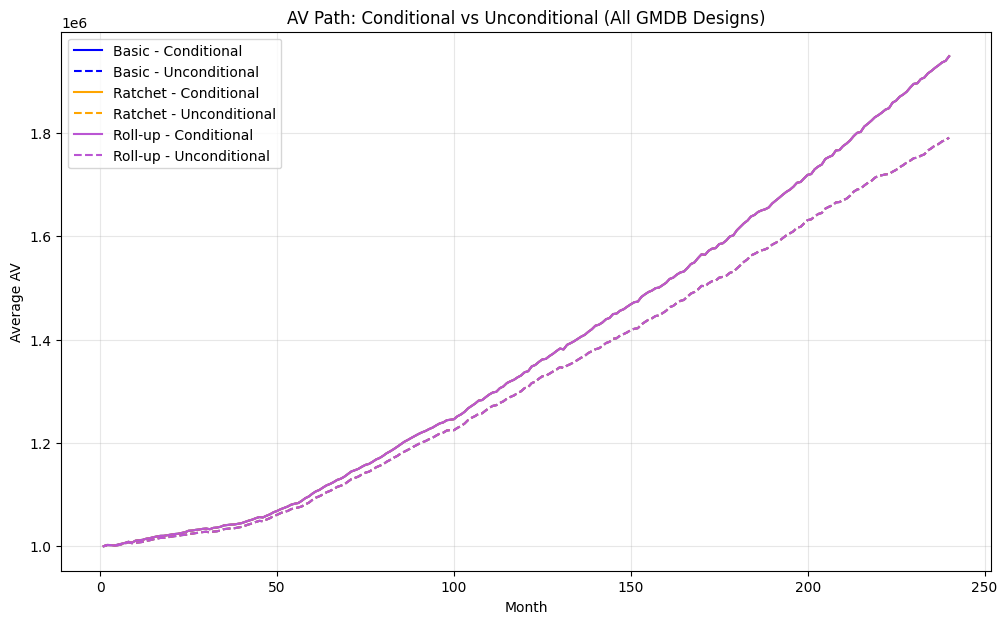

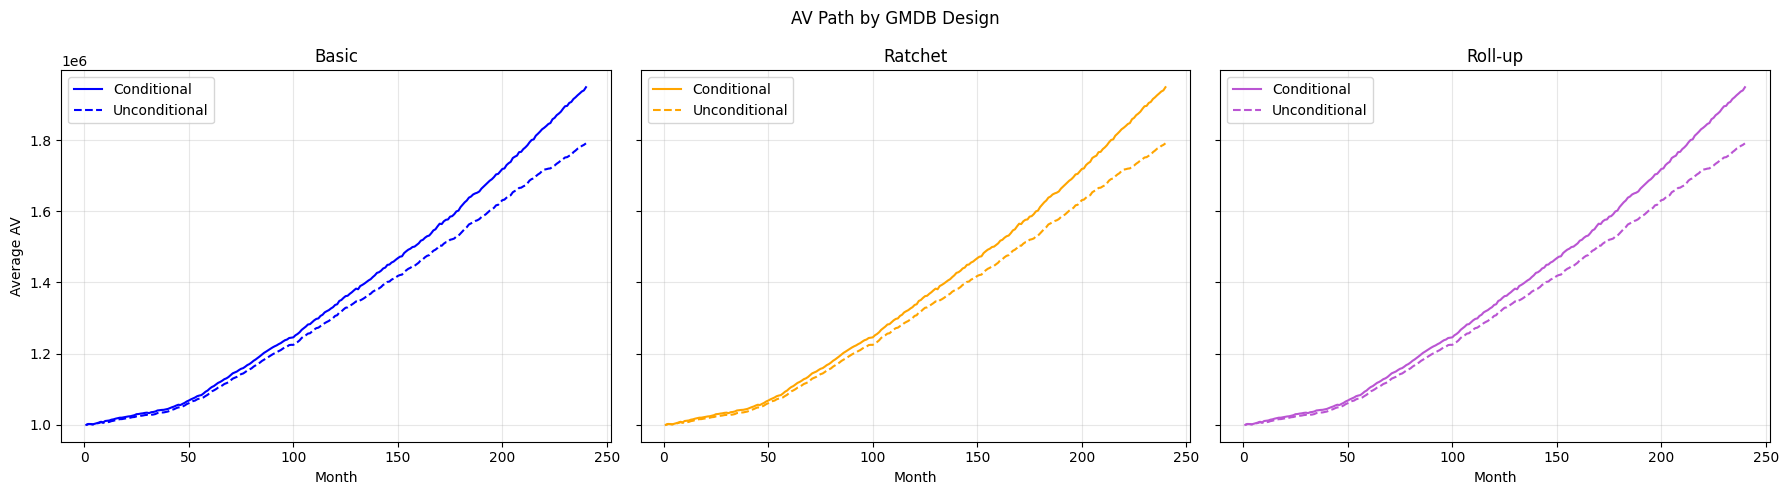

In [107]:
# @title
mc_table_format = mc_table.copy()

for col in ["Basic", "Ratchet", "Roll-up"]:
    mc_table_format[col] = mc_table_format[col].apply(lambda x: f"{x:,.4f}" if pd.notnull(x) else "")

display(mc_table_format.style
    .hide(axis="index")
    .set_properties(subset=["Metric"], **{"text-align": "left"})
    .set_properties(subset=["Basic", "Ratchet", "Roll-up"], **{"text-align": "right"})
    .set_table_styles([
        {"selector": "th.col_heading", "props": [("text-align", "center")]},
        {"selector": "th.col_heading.level0.col0", "props": [("text-align", "left")]}
        ])
    )
print("\n")
plot_av_paths(metrics_basic, metrics_ratchet, metrics_rollup, COLORS)


### 5.2 Uncondition Death Benefit & Guarantee Cost Distribution

📌 **觀察 ( Uncondition反映所有情境下的DB、GC分布 )：**  
Uncondition 下死亡給付平均落在14 ~ 20萬之間，因死亡率為 8.2%，平均死亡給付會被非死亡案件稀釋。  
而 VaR 作為整體風險衡量，Basic、Ratchet 的 p95 皆為160萬，顯示大部分案件兩種方式並無差異，配合最下面死亡事件的給付整理表，可看出平均 DB 的差異來源為少數案件。
但 Roll-up GC 會穩定成長的情況下 DB 跟 GC 就與前兩種有明顯差異。


📌 **死亡給付整理：在此模型設計下會有四種情況**
1. AV >= GB > 160萬  ->  basic: AV ；ratchet: AV   
2. GB > AV & AV > 160萬  ->  basic: AV ；ratchet: GB    **-> 差異來源**  
3. GB > 160萬 & AV <= 160萬  ->  basic: 160 ；ratchet: GB  **-> 差異來源**
4. GB = 160萬 & AV <= 160萬  ->  basic: 160 ； ratchet: 160

In [108]:
gmdb_table_uncond = gmdb_table.iloc[:7].copy()
gmdb_table_uncond_format = gmdb_table_uncond.copy()
for col in ["Basic", "Ratchet", "Roll-up"]:
    gmdb_table_uncond_format[col] = gmdb_table_uncond_format[col].apply(
        lambda x: f"{x:,.4f}" if pd.notnull(x) else "")
display(gmdb_table_uncond_format.style.hide(axis="index")
    .set_properties(subset=["Metric"], **{"text-align": "left"})
    .set_properties(subset=["Basic", "Ratchet", "Roll-up"], **{"text-align": "right"})
    .set_table_styles([
        {"selector": "th.col_heading", "props": [("text-align", "center")]},
        {"selector": "th.col_heading.level0.col0", "props": [("text-align", "left")]}
    ]))
print("\n", df_check["死亡給付"].value_counts())

Metric,Basic,Ratchet,Roll-up
Unconditional Mean Death Benefit,"149,716.5961","153,065.4375","197,812.8873"
Unconditional P95 Death Benefit,"1,600,000.0000","1,600,000.0000","2,249,143.0553"
Unconditional P99 Death Benefit,"2,256,778.8593","2,256,778.8593","2,798,707.3177"
Unconditional Mean Guarantee Cost,"26,248.5322","29,597.3736","74,344.8234"
Unconditional Trigger Rate,0.0560,0.0670,0.0760
Unconditional P95 Guarantee Cost,"45,490.3692","178,829.3543","776,388.3348"
Unconditional P99 Guarantee Cost,"678,173.4643","678,173.4643","1,528,437.5385"



 死亡給付
basic: 160 ； ratchet: 160    50
basic: av ；ratchet: av       15
basic: av ；ratchet: gb       11
basic: 160 ；ratchet: gb       6
Name: count, dtype: int64


### 5.3 Conditional Death Benefit Distribution

📌 **觀察 ( DB 看給付規模 ) ：**

 Roll-up 設計顯著提高死亡給付的平均值與中位數，反映其 guarantee base 隨時間成長，使多數情境下的給付水準提升。
 Ratchet 雖可在市場高點鎖定 guarantee，但在本模擬設定下，多數死亡情境中 GB 並未高於最終 AV，因此其整體死亡給付與 Basic 接近。

 值得注意的是 p95 非常接近、 p99 完全一樣，顯示極端情境主要由高帳戶價值(投資報酬表現非常好的情況) 主導，而非 guarantee 結構。  

📌 **Insight ：**  
GMDB 設計主要影響下行風險，而對上行潛力影響有限。

Metric,Basic,Ratchet,Roll-up
Conditional Mean Death Benefit,"1,825,812.1478","1,866,651.6769","2,412,352.2847"
Conditional Median Death Benefit,"1,600,000.0000","1,600,000.0000","2,456,184.9075"
Conditional P95 Death Benefit,"3,004,062.7230","3,017,255.3892","3,011,555.8759"
Conditional P99 Death Benefit,"3,651,355.1438","3,651,355.1438","3,651,355.1438"


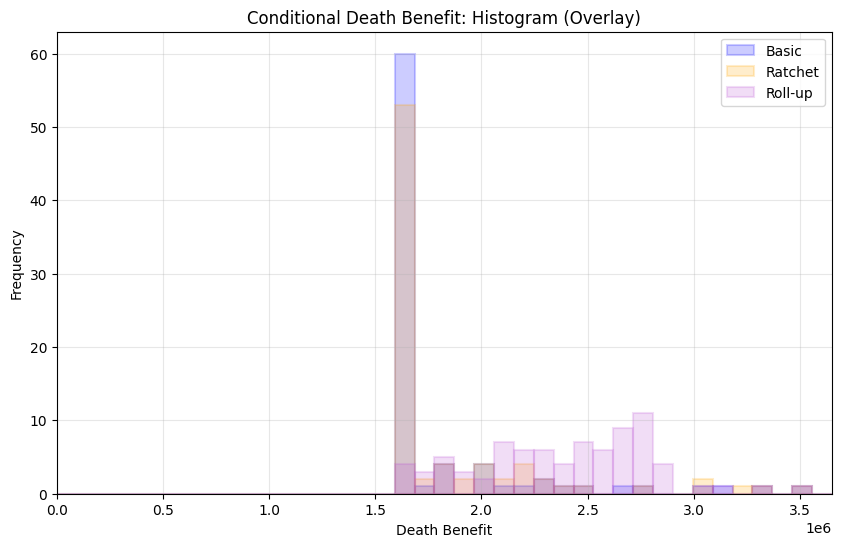

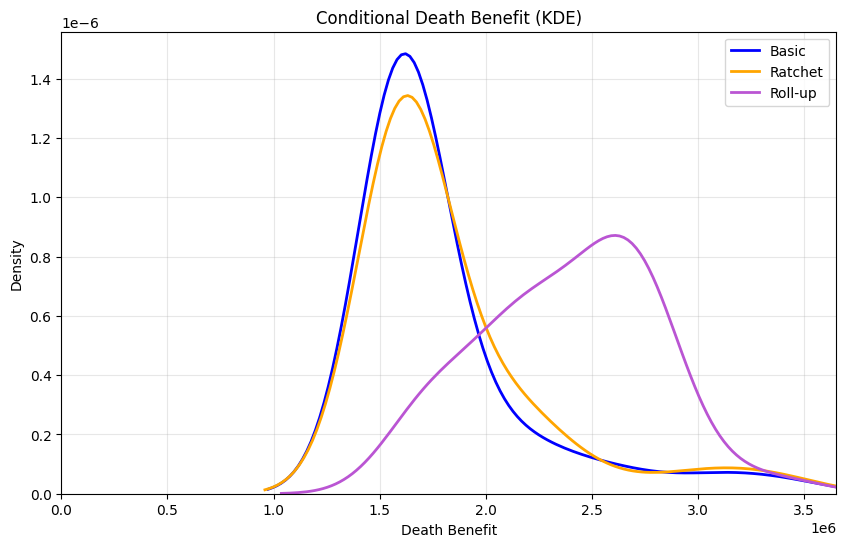

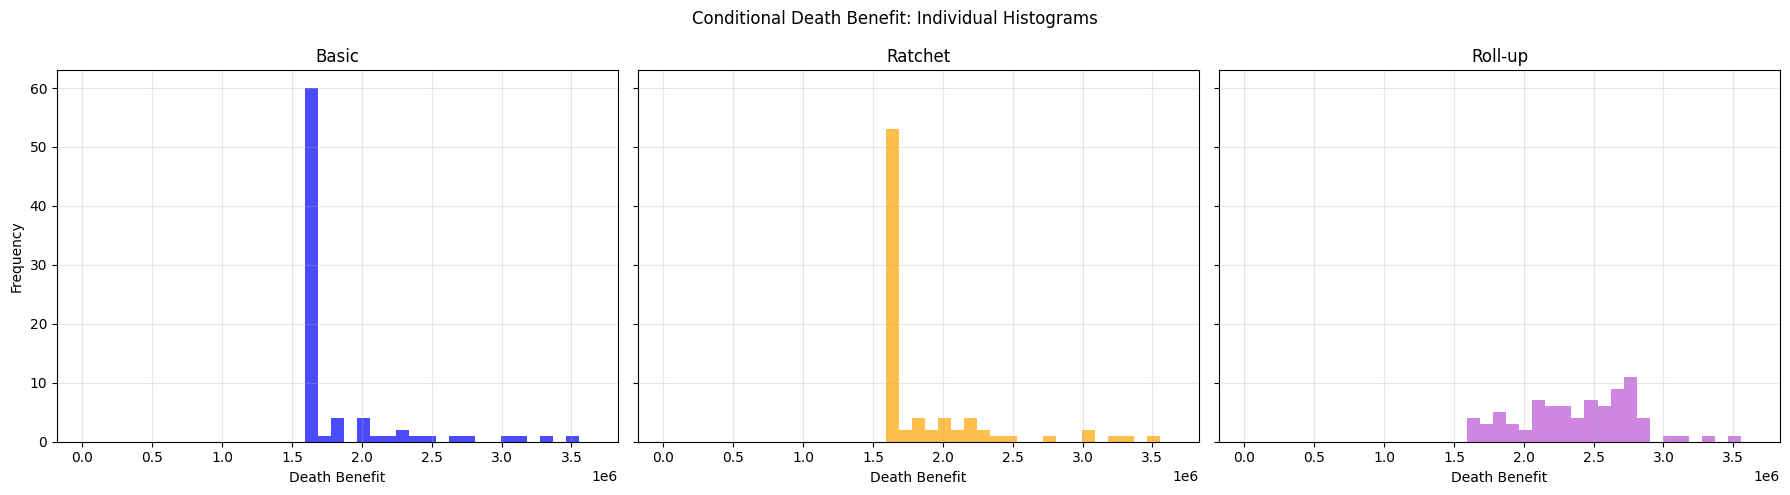

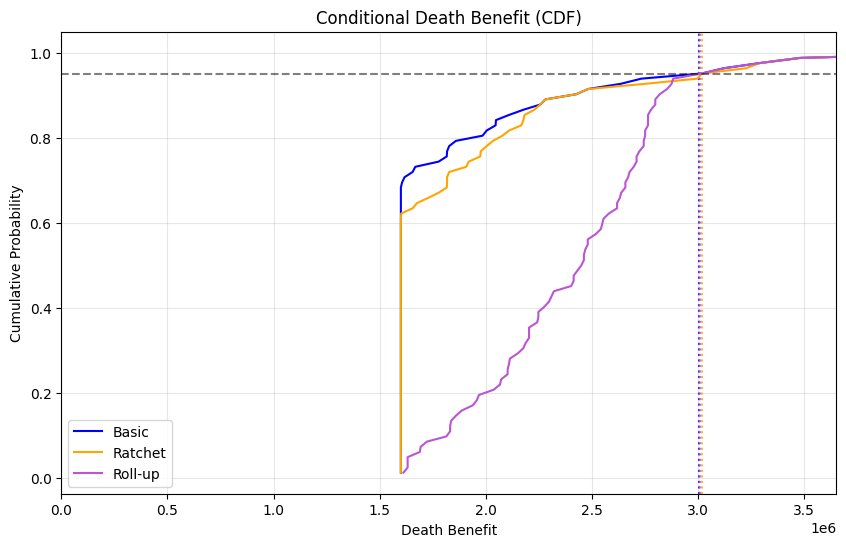

In [109]:
gmdb_table_cond = gmdb_table.iloc[7:11].copy()
gmdb_table_cond_format = gmdb_table_cond.copy()
for col in ["Basic", "Ratchet", "Roll-up"]:
    gmdb_table_cond_format[col] = gmdb_table_cond_format[col].apply(
        lambda x: f"{x:,.4f}" if pd.notnull(x) else "")
display(gmdb_table_cond_format.style.hide(axis="index")
    .set_properties(subset=["Metric"], **{"text-align": "left"})
    .set_properties(subset=["Basic", "Ratchet", "Roll-up"], **{"text-align": "right"})
    .set_table_styles([
        {"selector": "th.col_heading", "props": [("text-align", "center")]},
        {"selector": "th.col_heading.level0.col0", "props": [("text-align", "left")]}
    ]))
# 繪圖指令
plot_overlay_histogram({"Basic": basic_db, "Ratchet": ratchet_db, "Roll-up": rollup_db},
    title="Conditional Death Benefit: Histogram (Overlay)", xlabel="Death Benefit")

plot_distribution_annotated({"Basic": basic_db, "Ratchet": ratchet_db, "Roll-up": rollup_db},
    title="Conditional Death Benefit", xlabel="Death Benefit", mode="kde")

plot_individual_histogram({"Basic": basic_db, "Ratchet": ratchet_db, "Roll-up": rollup_db},
    title="Conditional Death Benefit: Individual Histograms", xlabel="Death Benefit")

plot_distribution_annotated({"Basic": basic_db, "Ratchet": ratchet_db, "Roll-up": rollup_db},
    title="Conditional Death Benefit", xlabel="Death Benefit", mode="cdf")

### 5.4 Conditional Guarantee Cost Distribution

📌 **觀察 ( GC 反映公司承擔的額外風險 ) ：**  
在conditional（已發生死亡）情境下，三種 GMDB 設計的差異明顯，其中 Roll-up 顯著提高 GC 與 tail risk，整體成本提升。而 Ratchet 相較 Basic 雖然提升平均 GC、 trigger 機率，但對 tail risk 的影響有限。  
* **Mean Guarantee Cost**  
以Basic為基準，Roll-up 設計使 guarantee base 隨時間成長，因此在死亡發生時，公司需承擔顯著較高的額外給付成本；相較之下，Ratchet 僅在市場曾達高點時才提升 guarantee，平均影響較為溫和。

* **Trigger Rate**  
Roll-up 幾乎在所有死亡情境下觸發，顯示其設計本質上將大部分市場風險轉移至保險公司；Ratchet 則介於兩者之間。

* **P95 / P99 / Worst 5% Mean**  
Basic 與 Ratchet 的 95%、99% 分位數及最差 5% 情境之平均損失相同，表示 Ratchet 並未在極端市場下顯著惡化損失。 此外，在 P95 ~ P99 的放大程度相較 Roll-up 輕微，代表它的 tail risk 是受控制的，風險結構較穩定。   
Roll-up 的 95%、99% 分位數及最差 5% 情境之平均損失顯著高於其他設計,顯示其 tail risk 顯著集中，公司風險及成本提升。

📌 **Insight**  
1. Ratchet 雖提高 guarantee 被觸發的機率，但由於 guarantee base 受限於歷史 AV，死亡可能發生於較早期，加上lock-in頻率為一年一次，導致其在極端情境下並未顯著高於 Basic。
2. Roll-up 結構使 guarantee 隨時間累積，即使市場表現不佳，仍會形成持續增長的負債，導致在死亡發生時產生顯著較大的 guarantee cost。

Metric,Basic,Ratchet,Roll-up
Conditional Mean Guarantee Cost,"320,104.0512","360,943.5802","906,644.1881"
Conditional Trigger Rate,0.6829,0.8171,0.9268
Conditional P95 Guarantee Cost,"916,126.4385","916,126.4385","1,662,081.2362"
Conditional P99 Guarantee Cost,"977,597.9856","977,597.9856","2,125,561.9181"
Worst 5% Mean Guarantee Cost (Conditional),"954,618.2510","954,618.2510","1,955,866.0768"


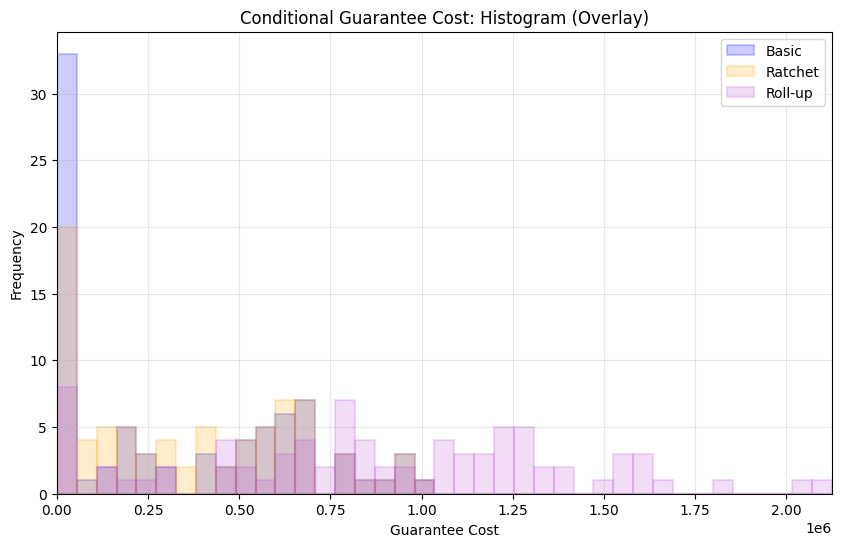

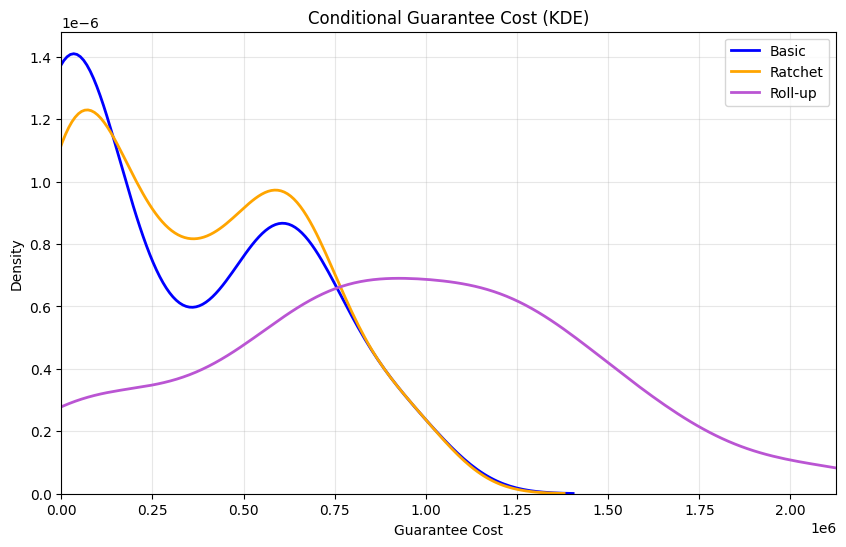

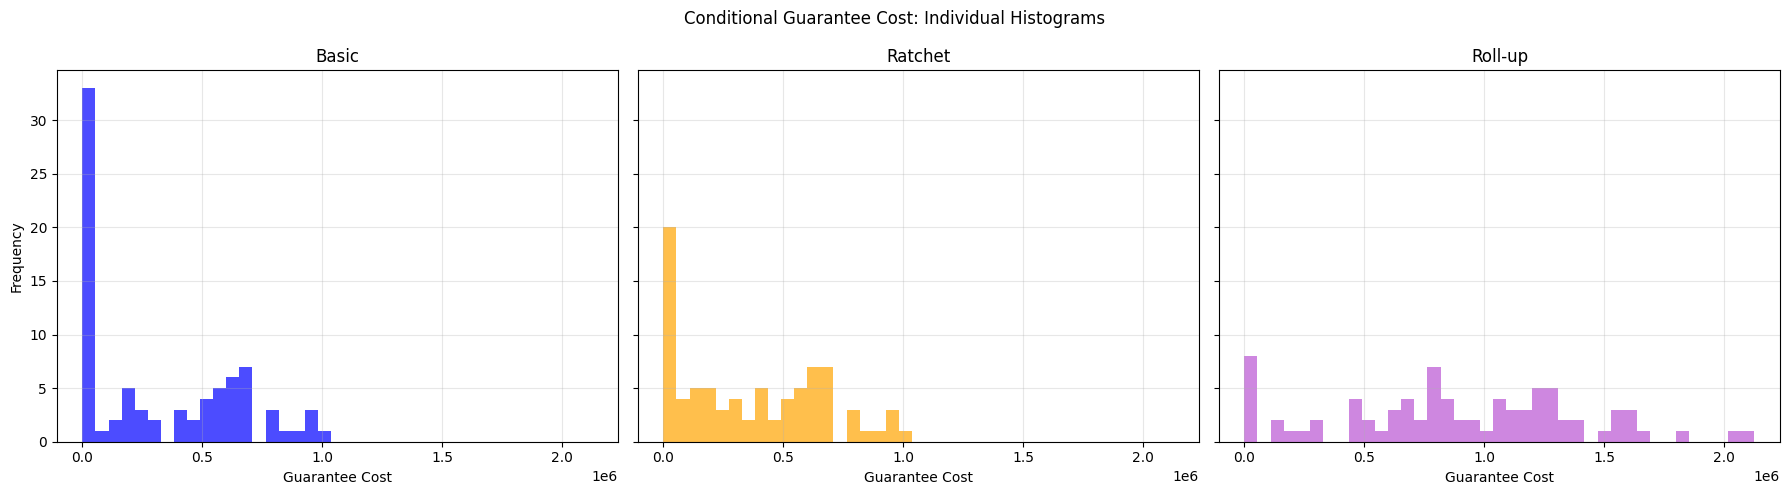

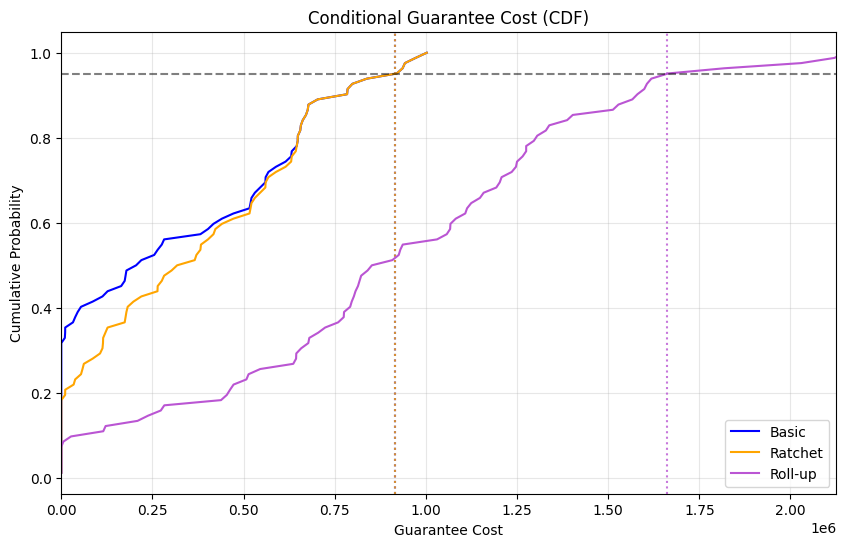

In [110]:
gmdb_table_cond_gc = gmdb_table.iloc[11:].copy()
gmdb_table_cond_gc_format = gmdb_table_cond_gc.copy()
for col in ["Basic", "Ratchet", "Roll-up"]:
    gmdb_table_cond_gc_format[col] = gmdb_table_cond_gc_format[col].apply(
        lambda x: f"{x:,.4f}" if pd.notnull(x) else "")

display(gmdb_table_cond_gc_format.style.hide(axis="index")
    .set_properties(subset=["Metric"], **{"text-align": "left"})
    .set_properties(subset=["Basic", "Ratchet", "Roll-up"], **{"text-align": "right"})
    .set_table_styles([
        {"selector": "th.col_heading", "props": [("text-align", "center")]},
        {"selector": "th.col_heading.level0.col0", "props": [("text-align", "left")]}
    ]))
plot_overlay_histogram({"Basic": basic_gc, "Ratchet": ratchet_gc, "Roll-up": rollup_gc},
    title="Conditional Guarantee Cost: Histogram (Overlay)",xlabel="Guarantee Cost")
plot_distribution_annotated({"Basic": basic_gc, "Ratchet": ratchet_gc, "Roll-up": rollup_gc},
    title="Conditional Guarantee Cost", xlabel="Guarantee Cost", mode="kde")

plot_individual_histogram({"Basic": basic_gc, "Ratchet": ratchet_gc, "Roll-up": rollup_gc},
    title="Conditional Guarantee Cost: Individual Histograms", xlabel="Guarantee Cost")
plot_distribution_annotated({"Basic": basic_gc, "Ratchet": ratchet_gc, "Roll-up": rollup_gc},
    title="Conditional Guarantee Cost", xlabel="Guarantee Cost", mode="cdf")

### 5.5 Risk-Neutral Valuation of GMDB Guarantee
在 Risk-neutral 下，保證成本的現值可表示為：

$$\text{GMDB Value} = \mathbb{E}^{Q}\left[e^{-rt}\cdot GC\right]$$

其中：$$GC = \max(\text{Guarantee} - AV, 0)$$

此 payoff 結構可視為保險公司提供保戶一個**內嵌賣權（embedded put option）**，因上述估值結果可解讀為該保證在市場上的經濟成本。

📌 **觀察 ( 無套利條件下的保證成本 ) ：**

Risk-neutral 定價結果顯示，Basic 與 Ratchet 的 guarantee cost 相近，表示 ratchet 機制雖提供額外保障，但其經濟成本增加有限；相對地，Roll-up 設計顯著提高 guarantee cost，反映其 guarantee base 隨時間成長，增加了保證被觸發的機率與 tail risk。

📌 **Insight ：**  
此結果與各商品設計的特性一致(與前面real-world模擬觀察一致)，說明不同保證機制對經濟成本的影響如下：

- **Basic**：保證水準固定，因此保證成本最低。
- **Ratchet**：雖具備鎖定高點的機制，但其成本僅略高於 Basic，顯示其額外保障的經濟成本相對有限。
- **Roll-up**：由於保證基準隨時間成長，使得保證更容易處於價內（in-the-money）狀態，因此顯著提高保證成本。

📌 **Real-world vs Risk-neutral ：**

實際損失（real-world）反映的是在既定假設下的平均發生結果；而市場一致評價（risk-neutral）則反映在無套利條件下，對極端情境與下檔風險的經濟定價。因此，兩者在數值與意義上可能存在差異：實際會賠多少 vs 市場覺得值多少。

此外需注意，conditional 保證成本反映的是「發生死亡時的平均損失」，而 risk-neutral 價值則為所有情境下的折現期望值，兩者在定義上不同，故不可直接比較其數值大小。

In [117]:
sim_basic_pricing = Simulator(config_basic, coi_table, mortality_table, seed=42)
price_basic = sim_basic_pricing.price_gmdb_rn(1000, r=0.02)
sim_ratchet_pricing = Simulator(config_ratchet, coi_table, mortality_table, seed=42)
price_ratchet = sim_ratchet_pricing.price_gmdb_rn(1000, r=0.02)
sim_rollup_pricing = Simulator(config_rollup, coi_table, mortality_table, seed=42)
price_rollup = sim_rollup_pricing.price_gmdb_rn(1000, r=0.02)


price_data = {"Guarantee Type": ["Basic", "Ratchet", "Roll-up"], "GMDB Price": [price_basic, price_ratchet, price_rollup]}
df_price = pd.DataFrame(price_data)
df_price["GMDB Price"] = df_price["GMDB Price"].map(lambda x: f"{x:,.4f}")
styled_price = df_price.style.hide(axis='index').set_properties(**{'text-align': 'left'}, subset=['Guarantee Type']).set_properties(**{'text-align': 'right'}, subset=['GMDB Price'])

display(styled_price)

Guarantee Type,GMDB Price
Basic,"34,097.4664"
Ratchet,"34,792.2075"
Roll-up,"77,164.1485"


## 6. Profit Distribution

📌 **觀察 (保單整體盈利能力) ：**

* **平均利潤現值**
Basic 與 Ratchet 現值皆為正，表示在目前費率與假設下，相關費用收入足以覆蓋保證成本；其中 Ratchet 僅略低於 Basic ，顯示額外保障對整體盈利影響有限。相較之下，Roll-up 現值為負，顯示保證成本已超過保費收入，呈現定價不足（underpricing）。平均利潤受少數極端虧損影響，因此僅觀察 mean 可能低估產品的尾端風險。

* **Median、P5**
三種設計的中位數相同，且多數情境下均為正報酬，表示保單在大部分情境下皆能穩定獲利。但在少數情況下（約 8%），保證機制被觸發時會產生虧損，形成明顯的尾端風險（tail risk）。其中 Roll-up 在 P5 下的虧損顯著高於其他設計，顯示其對下檔風險的放大效果最為明顯。

此結果反映 GMDB 商品具有「小幅穩定獲利，但伴隨少數極端虧損」的結構，與賣出賣權（short put option）的風險特性一致。

*profit distribution 用 log scale 呈現 ，因大部分獲利集中少數區間，而 tail loss 雖然發生機率低，但對風險評估非常重要


Metric,Basic,Ratchet,Roll-up
mean,"16,925.4031","14,559.1833","-18,722.2021"
median,"131,454.6340","131,454.6340","131,454.6340"
p5,"-1,145,815.2663","-1,178,607.3289","-1,673,094.2621"
p95,"152,407.9392","152,407.9392","152,407.9392"
p99,"164,025.9892","164,025.9892","164,025.9892"
loss_prob,0.0820,0.0820,0.0820


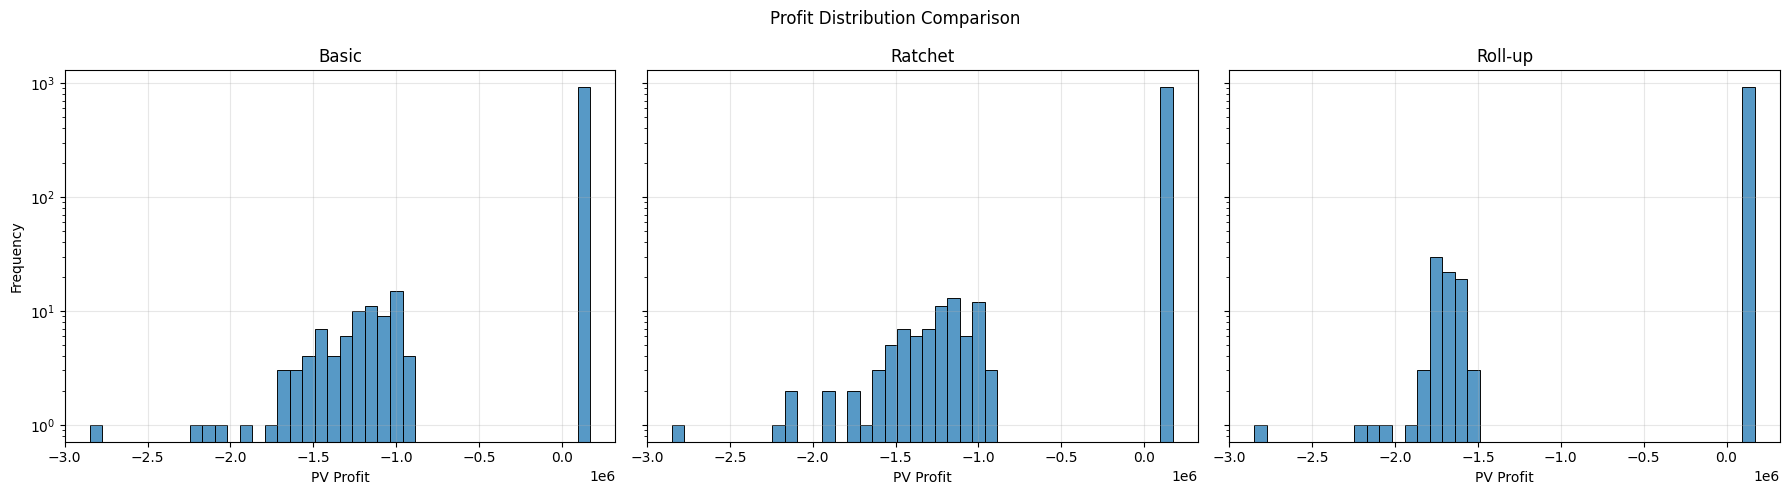

In [121]:
pv_basic = get_profit_metrics(all_basic, config_basic.discount_rate, monthly_expense = 0.0)
pv_ratchet = get_profit_metrics(all_ratchet, config_ratchet.discount_rate, monthly_expense = 0.0)
pv_rollup = get_profit_metrics(all_rollup, config_rollup.discount_rate, monthly_expense = 0.0)

table_basic = pv_basic["table"]
table_ratchet = pv_ratchet["table"]
table_rollup = pv_rollup["table"]

table_basic.columns = ['Metric', 'Basic']
table_ratchet.columns = ['Metric', 'Ratchet']
table_rollup.columns = ['Metric', 'Roll-up']

# 進行合併 (依據 Metric 欄位)
df_merged = table_basic.merge(table_ratchet, on='Metric').merge(table_rollup, on='Metric')
numeric_cols = df_merged.columns.drop('Metric')
df_merged[numeric_cols] = df_merged[numeric_cols].map(lambda x: f"{x:,.4f}" if isinstance(x, (int, float)) else x)
styled_df = df_merged.style.set_properties(**{'text-align': 'left'}, subset=['Metric']).set_properties(**{'text-align': 'right'}, subset=numeric_cols).hide(axis='index') # 隱藏左側索引編號，更像正式報表

display(styled_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
sns.histplot(pv_basic["profit_by_path"]["pv_profit"], bins=40, ax=axes[0]) # Basic
axes[0].set_title("Basic")
sns.histplot(pv_ratchet["profit_by_path"]["pv_profit"], bins=40, ax=axes[1]) # Ratchet
axes[1].set_title("Ratchet")
sns.histplot(pv_rollup["profit_by_path"]["pv_profit"], bins=40, ax=axes[2]) # Roll-up
axes[2].set_title("Roll-up")

for ax in axes:
    ax.set_xlabel("PV Profit")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Frequency")
plt.yscale("log")
plt.suptitle("Profit Distribution Comparison")
plt.tight_layout()
plt.show()

## 7. 總結

Real-world 模擬結果可觀察到，在此模型設計下不同保證結構對帳戶價值（AV）沒有產生影響，但在死亡給付（DB）與保證成本（GC）上呈現顯著差異。當 AV 高於保證水準時，各設計之給付結果趨於一致；然而在 AV 低於保證水準時，保證機制開始發揮作用，並形成明顯差異。

Basic 設計提供最低成本與最穩定風險結構 (guarantee 固定對市場變動不敏感，不隨時間或市場路徑放大風險，整體損失分布較穩定) ；Ratchet 雖提高 guarantee 觸發機率，但對尾端風險影響有限；Roll-up 則大幅提升平均成本與 tail risk，在極端情境下可能造成顯著損失。

進一步分析利潤顯示，GMDB 商品具有典型的「小幅穩定獲利，但伴隨少數極端虧損」之結構。大部分情境下，保險公司透過費用收入（fee 、COI）獲利；但在少數情境（約對應死亡發生）中，若保證被觸發，將產生顯著虧損，形成明顯的尾端風險（tail risk）。此種特性與賣出賣權（short put option）之風險結構一致。

在三種設計中，Basic 與 Ratchet 的利潤表現相近，顯示 ratchet 雖提供額外保障，但其對整體成本與風險影響有限；相較之下，Roll-up 設計顯著放大下檔風險，使得平均利潤轉為負值，表示在既定費率下存在定價不足（underpricing）。

在 risk-neutral 評價結果中，Basic 與 Ratchet 的保證成本接近，而 Roll-up 則顯著提高保證價值。此結果反映，保證機制的經濟成本主要來自於下檔風險，而非上檔報酬。特別是 Roll-up 由於保證基準隨時間成長，增加了保證處於價內（in-the-money）的機率，進而顯著提高其 embedded option value。

🔎 整體而言，本研究顯示：

1. 不同 GMDB 設計在一般情境下的損益分布相近，但其差異主要來自少數極端虧損情境，因此平均結果的差異主要由 tail risk 所驅動，GMDB 設計對尾端風險影響更為明顯。
2. Ratchet 屬於相對低成本的保障升級；Roll-up 雖提供較高保障，但需搭配更高費率或風險管理機制。
3. 此外，real-world 模擬與 risk-neutral 評價分別對應「實際會發生什麼」與「市場覺得值多少」，兩者提供互補的資訊，對於商品設計、定價與風險管理皆具有重要參考價值。



## 8. ( 補充 ) 死亡案件資料 & 模擬結果驗算

In [122]:
# 資料驗證：check 死亡案件

print(df_check["死亡給付"].value_counts())
print("\n","*所有死亡事件")
pd.set_option("display.max_rows", None)
display(df_check)

df_check["db_diff_ratchet_vs_basic"] = df_check["db_ratchet"] - df_check["db_basic"]
cond23_df = df_check[df_check["死亡給付"].isin(["basic: av ；ratchet: gb", "basic: 160 ；ratchet: gb"])].copy()
cond23_df[["死亡給付","death_month","av_at_death","gb_ratchet","db_basic","db_ratchet","db_diff_ratchet_vs_basic"]]

print("\n","*造成差異的死亡事件(basic: AV ；ratchet: GB 或 basic: 160 ；ratchet: GB)")
display(cond23_df)

# Check difference of conditional mean death benefit between basic and ratchet >> 符合
c = cond23_df["db_diff_ratchet_vs_basic"].sum()
c /= 82
print("\n","*Difference of conditional mean death benefit between basic and ratchet:" ,c)

# Conditional p95 chack >> 符合
db_sorted = np.sort(compare_df["db_basic"].values)
db_sorted
x76 = db_sorted[76]
x77 = db_sorted[77]

dbr_sorted = np.sort(compare_df["db_ratchet"].values)
xr76 = dbr_sorted[76]
xr77 = dbr_sorted[77]

p95_manual = x76 + 0.95 * (x77 - x76)
pr95_manual = xr76 + 0.95 * (xr77 - xr76)
print("\n","*Conditional P95 Death Benefit(basic & ratchet)", p95_manual, pr95_manual)

死亡給付
basic: 160 ； ratchet: 160    50
basic: av ；ratchet: av       15
basic: av ；ratchet: gb       11
basic: 160 ；ratchet: gb       6
Name: count, dtype: int64

 *所有死亡事件


,death_month,av_at_death,gb_basic,db_basic,gb_ratchet,db_ratchet,gb_rollup,db_rollup,死亡給付,db_diff_ratchet_vs_basic
0,9.0,9.516248e+05,1600000.0,1.600000e+06,1.600000e+06,1.600000e+06,1.631842e+06,1.631842e+06,basic: 160 ； ratchet: 160,0.000000
1,166.0,1.345156e+06,1600000.0,1.600000e+06,1.728286e+06,1.728286e+06,2.402325e+06,2.402325e+06,basic: 160 ；ratchet: gb,128285.832216
2,112.0,1.589410e+06,1600000.0,1.600000e+06,1.600000e+06,1.600000e+06,2.103121e+06,2.103121e+06,basic: 160 ； ratchet: 160,0.000000
3,9.0,9.543494e+05,1600000.0,1.600000e+06,1.600000e+06,1.600000e+06,1.631842e+06,1.631842e+06,basic: 160 ； ratchet: 160,0.000000
4,176.0,1.817706e+06,1600000.0,1.817706e+06,1.791120e+06,1.817706e+06,2.462235e+06,2.462235e+06,basic: av ；ratchet: av,0.000000
5,83.0,1.182578e+06,1600000.0,1.600000e+06,1.600000e+06,1.600000e+06,1.958128e+06,1.958128e+06,basic: 160 ； ratchet: 160,0.000000
6,229.0,3.018339e+06,1600000.0,3.018339e+06,3.018339e+06,3.018339e+06,2.805610e+06,3.018339e+06,basic: av ；ratchet: av,0.000000
7,225.0,6.574485e+05,1600000.0,1.600000e+06,1.600000e+06,1.600000e+06,2.778102e+06,2.778102e+06,basic: 160 ； ratchet: 160,0.000000
8,106.0,9.239998e+05,1600000.0,1.600000e+06,1.600000e+06,1.600000e+06,2.072267e+06,2.072267e+06,basic: 160 ； ratchet: 160,0.000000
9,100.0,2.109560e+06,1600000.0,2.109560e+06,2.167774e+06,2.167774e+06,2.041865e+06,2.109560e+06,basic: av ；ratchet: gb,58213.754830



 *造成差異的死亡事件(basic: AV ；ratchet: GB 或 basic: 160 ；ratchet: GB)


,death_month,av_at_death,gb_basic,db_basic,gb_ratchet,db_ratchet,gb_rollup,db_rollup,死亡給付,db_diff_ratchet_vs_basic
1,166.0,1.345156e+06,1600000.0,1.600000e+06,1.728286e+06,1.728286e+06,2.402325e+06,2.402325e+06,basic: 160 ；ratchet: gb,128285.832216
9,100.0,2.109560e+06,1600000.0,2.109560e+06,2.167774e+06,2.167774e+06,2.041865e+06,2.109560e+06,basic: av ；ratchet: gb,58213.754830
14,221.0,2.046338e+06,1600000.0,2.046338e+06,2.228468e+06,2.228468e+06,2.750864e+06,2.750864e+06,basic: av ；ratchet: gb,182129.866732
21,152.0,2.047933e+06,1600000.0,2.047933e+06,2.109813e+06,2.109813e+06,2.320893e+06,2.320893e+06,basic: av ；ratchet: gb,61879.611730
28,239.0,1.667951e+06,1600000.0,1.667951e+06,2.033879e+06,2.033879e+06,2.875577e+06,2.875577e+06,basic: av ；ratchet: gb,365927.809584
30,217.0,1.394803e+06,1600000.0,1.600000e+06,1.817437e+06,1.817437e+06,2.723893e+06,2.723893e+06,basic: 160 ；ratchet: gb,217436.944712
31,236.0,2.732805e+06,1600000.0,2.732805e+06,2.996659e+06,2.996659e+06,2.854405e+06,2.854405e+06,basic: av ；ratchet: gb,263853.323522
32,201.0,1.859273e+06,1600000.0,1.859273e+06,1.974103e+06,1.974103e+06,2.618628e+06,2.618628e+06,basic: av ；ratchet: gb,114829.505019
34,114.0,1.567941e+06,1600000.0,1.600000e+06,1.601812e+06,1.601812e+06,2.113508e+06,2.113508e+06,basic: 160 ；ratchet: gb,1811.578003
42,179.0,1.554965e+06,1600000.0,1.600000e+06,1.675884e+06,1.675884e+06,2.480498e+06,2.480498e+06,basic: 160 ；ratchet: gb,75884.204683



 *Difference of conditional mean death benefit between basic and ratchet: 40839.5290768639

 *Conditional P95 Death Benefit(basic & ratchet) 3004062.7230462404 3017255.3892223393
